In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [94]:
df = pd.read_csv("/kaggle/input/insurance/insurance.csv")

In [95]:
df

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.00,male,23.20,91,Yes,0,No,southeast,1121.87
1,2,24.00,male,30.10,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.30,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.70,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.10,100,No,0,No,northwest,1137.01
...,...,...,...,...,...,...,...,...,...,...
1335,1336,44.00,female,35.50,88,Yes,0,Yes,northwest,55135.40
1336,1337,59.00,female,38.10,120,No,1,Yes,northeast,58571.07
1337,1338,30.00,male,34.50,91,Yes,3,Yes,northwest,60021.40
1338,1339,37.00,male,30.40,106,No,0,Yes,southeast,62592.87


In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1340 non-null   int64  
 1   age            1335 non-null   float64
 2   gender         1340 non-null   object 
 3   bmi            1340 non-null   float64
 4   bloodpressure  1340 non-null   int64  
 5   diabetic       1340 non-null   object 
 6   children       1340 non-null   int64  
 7   smoker         1340 non-null   object 
 8   region         1337 non-null   object 
 9   claim          1340 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 104.8+ KB


In [97]:
df.tail(5)

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
1335,1336,44.00,female,35.50,88,Yes,0,Yes,northwest,55135.40
1336,1337,59.00,female,38.10,120,No,1,Yes,northeast,58571.07
1337,1338,30.00,male,34.50,91,Yes,3,Yes,northwest,60021.40
1338,1339,37.00,male,30.40,106,No,0,Yes,southeast,62592.87
1339,1340,30.00,female,47.40,101,No,0,Yes,southeast,63770.43


In [98]:
df.shape

(1340, 10)

In [99]:
pd.set_option("display.float_format","{:.2f}".format)


In [100]:
df

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.00,male,23.20,91,Yes,0,No,southeast,1121.87
1,2,24.00,male,30.10,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.30,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.70,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.10,100,No,0,No,northwest,1137.01
...,...,...,...,...,...,...,...,...,...,...
1335,1336,44.00,female,35.50,88,Yes,0,Yes,northwest,55135.40
1336,1337,59.00,female,38.10,120,No,1,Yes,northeast,58571.07
1337,1338,30.00,male,34.50,91,Yes,3,Yes,northwest,60021.40
1338,1339,37.00,male,30.40,106,No,0,Yes,southeast,62592.87


In [101]:
df.duplicated().sum()


0

In [102]:
df.duplicated().sum().sum()


0

In [103]:
df.dropna(inplace=True)


In [104]:
df.shape

(1332, 10)

In [105]:
df.isna().sum().sum()


0

In [106]:
df.describe(include="all")

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
count,1332.00,1332.00,1332,1332.00,1332.00,1332,1332.00,1332,1332,1332.00
unique,NaN,NaN,2,NaN,NaN,2,NaN,2,4,NaN
top,NaN,NaN,male,NaN,NaN,No,NaN,No,southeast,NaN
freq,NaN,NaN,670,NaN,NaN,695,NaN,1058,442,NaN
mean,674.47,38.09,NaN,30.66,94.19,NaN,1.10,NaN,NaN,13325.25
std,384.70,11.11,NaN,6.12,11.45,NaN,1.21,NaN,NaN,12109.62
min,1.00,18.00,NaN,16.00,80.00,NaN,0.00,NaN,NaN,1121.87
25%,341.75,29.00,NaN,26.20,86.00,NaN,0.00,NaN,NaN,4760.16
50%,674.50,38.00,NaN,30.35,92.00,NaN,1.00,NaN,NaN,9412.97
75%,1007.25,47.00,NaN,34.73,99.00,NaN,2.00,NaN,NaN,16781.33


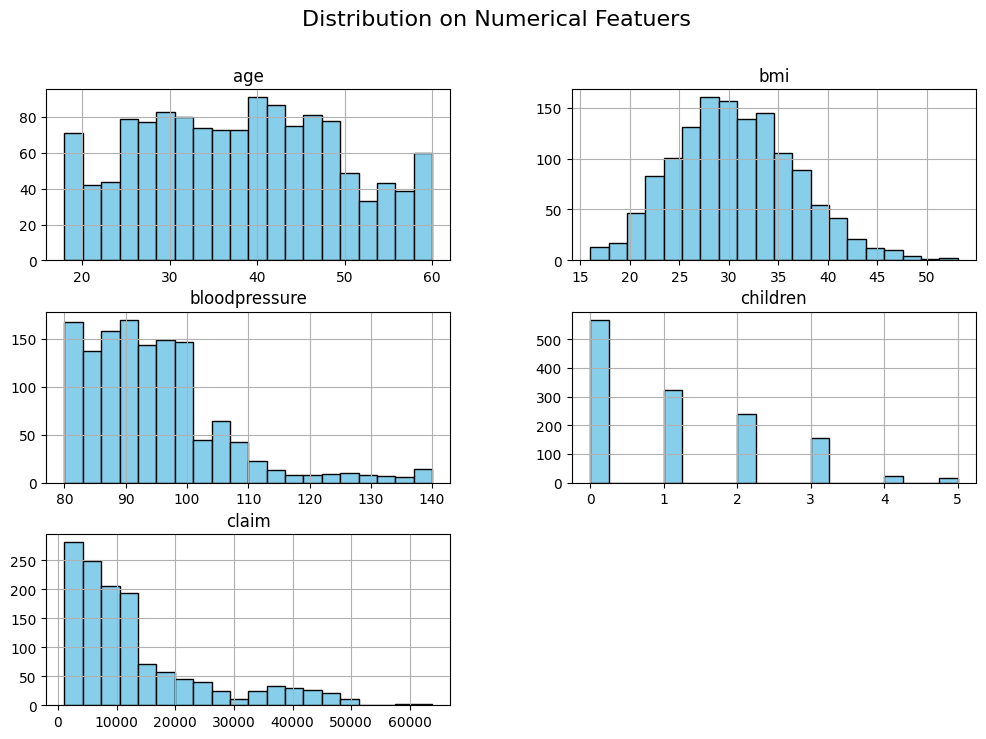

In [107]:
numeric_cols=["age","bmi","bloodpressure","children","claim"]
df[numeric_cols].hist(bins=20,figsize=(12,8),color="skyblue",edgecolor="black")
plt.suptitle("Distribution on Numerical Featuers",fontsize=16)
plt.show()

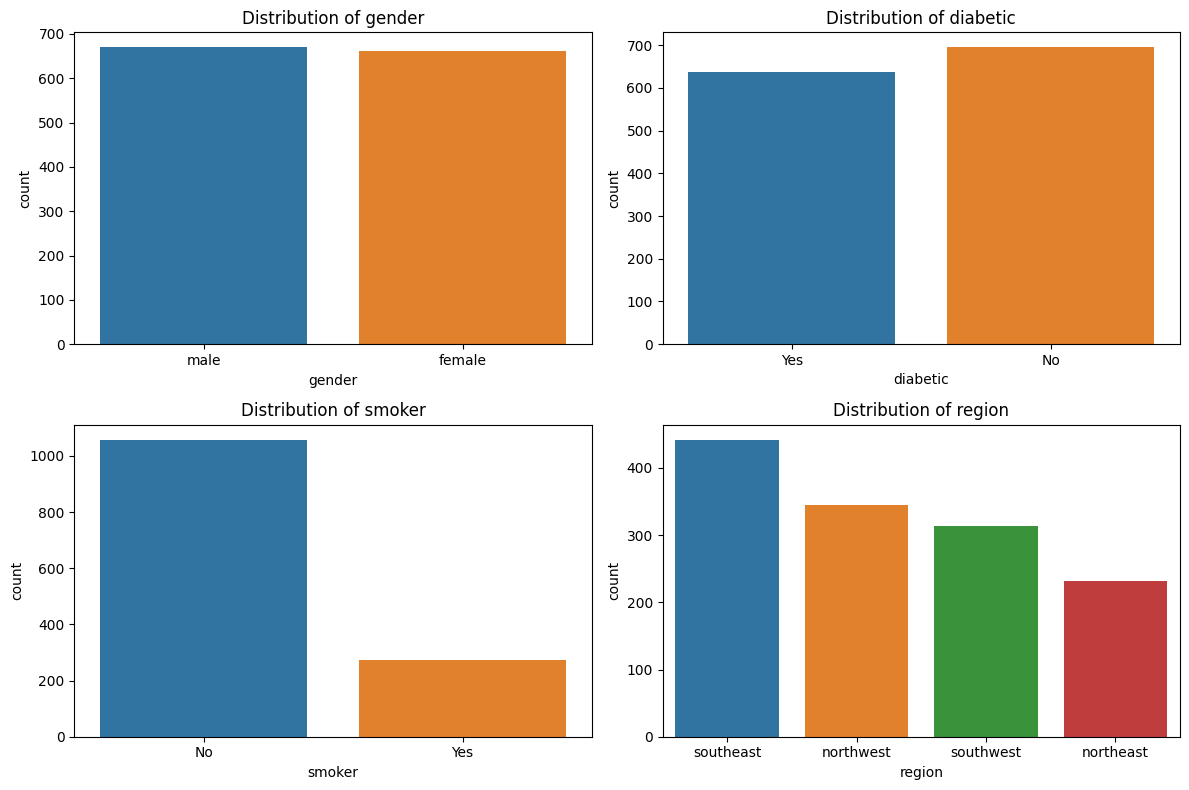

In [108]:
cat_cols = ["gender", "diabetic", "smoker", "region"]

plt.figure(figsize=(12, 8))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 2, i)              # Indented
    sns.countplot(data=df, x=col)     # Indented
    plt.title(f"Distribution of {col}") # Indented

plt.tight_layout()
plt.show()

In [109]:
df.groupby(["gender","smoker"])["claim"].mean().round(2)

gender  smoker
female  No        8762.30
        Yes      30679.00
male    No        8169.25
        Yes      33042.01
Name: claim, dtype: float64

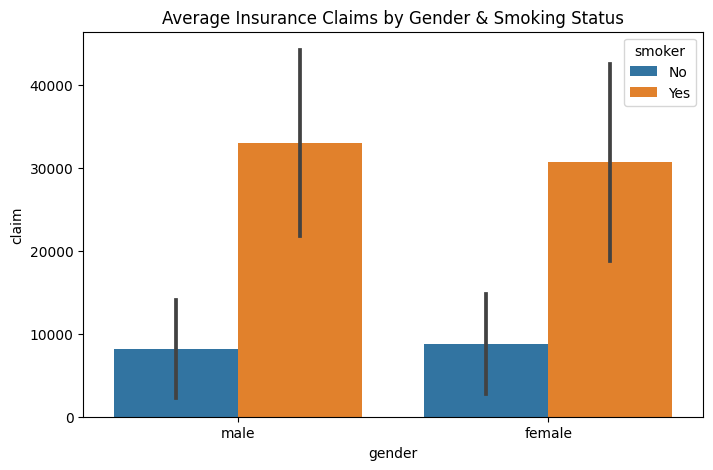

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

# 'estimator' defaults to mean, so we don't need to specify it.
# Note: 'errorbar' requires seaborn v0.12+. For older versions, use ci="sd".
sns.barplot(data=df, x="gender", y="claim", hue="smoker", errorbar="sd")

plt.title("Average Insurance Claims by Gender & Smoking Status")
plt.show()

In [111]:
pivot_region_diabatic=df.groupby(["region","diabetic"])["claim"].mean().unstack()

In [112]:
pivot_region_diabatic

diabetic,No,Yes
region,,
northeast,16966.86,16818.30
northwest,11442.83,12224.96
southeast,13578.72,12574.09
southwest,13069.91,12313.74


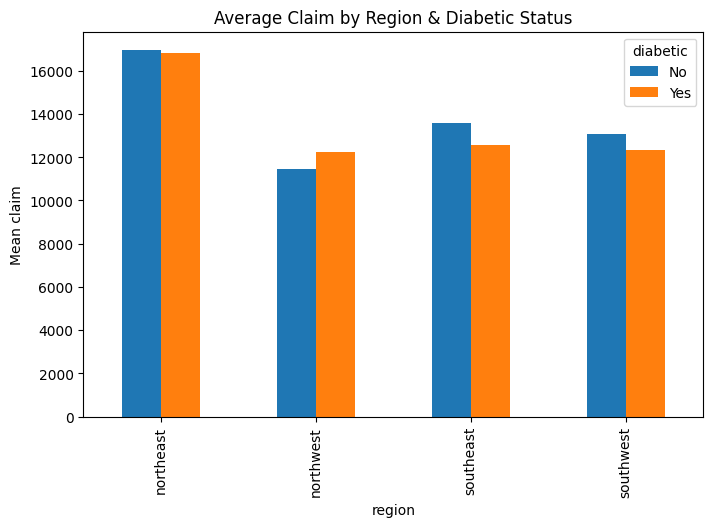

In [113]:
pivot_region_diabatic.plot(kind="bar", figsize=(8, 5))

plt.title("Average Claim by Region & Diabetic Status")
plt.ylabel("Mean claim")  # Fixed: 'ylable' -> 'ylabel'
plt.show()

In [114]:
pivot_table =pd.pivot_table(df,values="claim",index="region",columns="smoker", aggfunc="mean")
pivot_table 

smoker,No,Yes
region,,
northeast,11666.11,29673.54
northwest,8076.20,30192.00
southeast,7444.14,34845.00
southwest,8294.75,32269.06


In [115]:
pivot_table = pd.pivot_table(df, values="claim", index="children", columns="diabetic", aggfunc="mean")

pivot_table

diabetic,No,Yes
children,,
0,12967.40,11985.29
1,12730.46,12732.06
2,15567.77,14579.36
3,13807.61,17091.26
4,14106.63,13573.35
5,8519.04,9205.59


In [116]:
numeric_cols

['age', 'bmi', 'bloodpressure', 'children', 'claim']

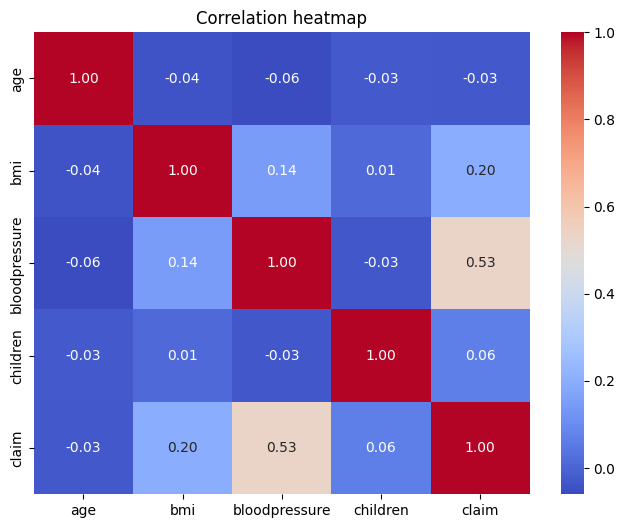

In [117]:
plt.figure(figsize=(8, 6))

# Calculate the correlation matrix first using .corr()
# Change 'true' to 'True' and '2f' to '.2f'
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation heatmap")
plt.show()

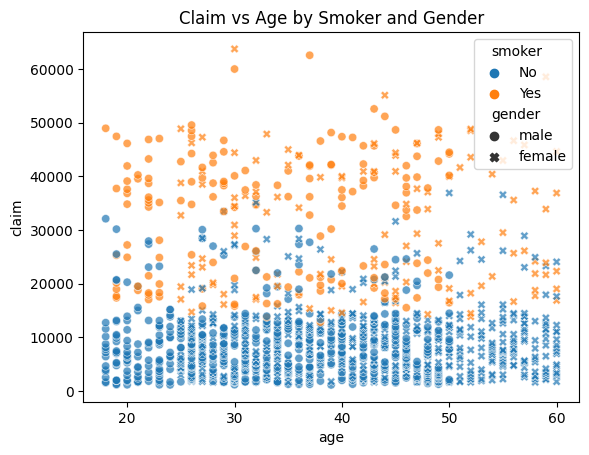

In [118]:
# Fixed: Added '=' after hue
sns.scatterplot(data=df, x="age", y="claim", hue="smoker", style="gender", alpha=0.7)

plt.title("Claim vs Age by Smoker and Gender")
plt.show()  # Fixed: plot.show() -> plt.show()

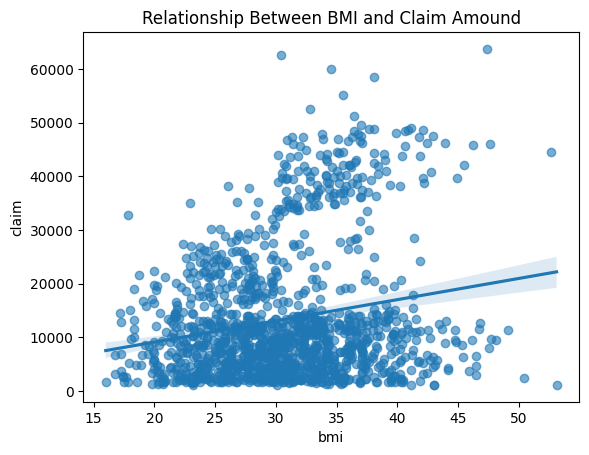

In [119]:
sns.regplot(data=df,x="bmi",y="claim",scatter_kws={"alpha":0.6})
plt.title("Relationship Between BMI and Claim Amound")
plt.show()

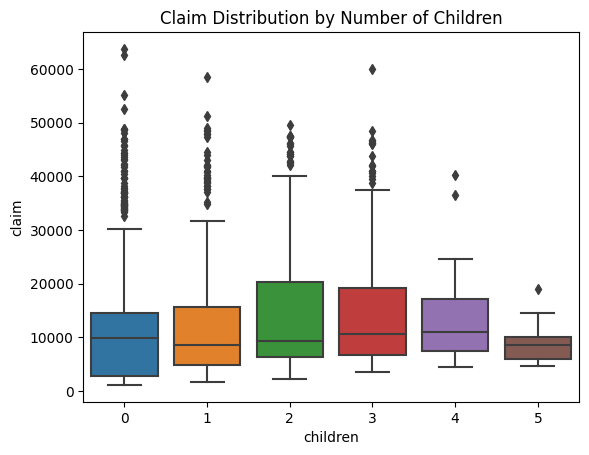

In [120]:
sns.boxplot(data=df,x="children",y="claim")
plt.title("Claim Distribution by Number of Children")
plt.show()

In [121]:
df["age_group"] = pd.cut(df["age"], bins=[0, 18, 30, 45, 60, 100], labels=["<18", "18-30", "31-45", "46-60", "61-100"])


In [122]:
df

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim,age_group
0,1,39.00,male,23.20,91,Yes,0,No,southeast,1121.87,31-45
1,2,24.00,male,30.10,87,No,0,No,southeast,1131.51,18-30
7,8,19.00,male,41.10,100,No,0,No,northwest,1146.80,18-30
8,9,20.00,male,43.00,86,No,0,No,northwest,1149.40,18-30
9,10,30.00,male,53.10,97,No,0,No,northwest,1163.46,18-30
...,...,...,...,...,...,...,...,...,...,...,...
1335,1336,44.00,female,35.50,88,Yes,0,Yes,northwest,55135.40,31-45
1336,1337,59.00,female,38.10,120,No,1,Yes,northeast,58571.07,46-60
1337,1338,30.00,male,34.50,91,Yes,3,Yes,northwest,60021.40,18-30
1338,1339,37.00,male,30.40,106,No,0,Yes,southeast,62592.87,31-45


In [123]:
df["age_group"].value_counts()

age_group
31-45     553
46-60     383
18-30     380
<18        16
61-100      0
Name: count, dtype: int64

/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


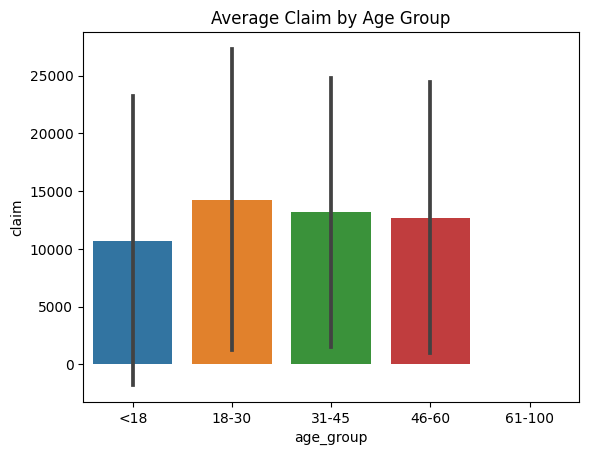

In [124]:
import seaborn as sns
import matplotlib.pyplot as plt

# Fix: Removed estimator="mean" (it is the default)
sns.barplot(data=df, x="age_group", y="claim", errorbar="sd")

plt.title("Average Claim by Age Group")
plt.show()

In [125]:
df["bmi_category"]=pd.cut(df["bmi"],bins=[0,18.5,24.9,29.9,100],labels=["Underweight","Normal","Overweight","Obese"])


In [126]:
df["bmi_category"].value_counts()

bmi_category
Obese          702
Overweight     387
Normal         222
Underweight     21
Name: count, dtype: int64

/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


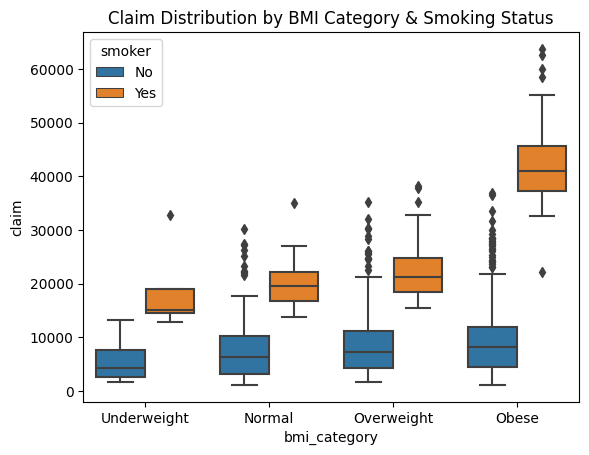

In [127]:
sns.boxplot(data=df,x="bmi_category",y="claim",hue="smoker")
plt.title("Claim Distribution by BMI Category & Smoking Status")
plt.show()

In [128]:
region_stats = df.groupby("region").agg(
    smoker_rate=("smoker", lambda x: (x == "Yes").mean() * 100),
    mean_claim=("claim", "mean")
).reset_index()

In [129]:
region_stats

,region,smoker_rate,mean_claim
0,northeast,29.00,16889.04
1,northwest,16.81,11794.22
2,southeast,20.59,13085.50
3,southwest,18.47,12723.13


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


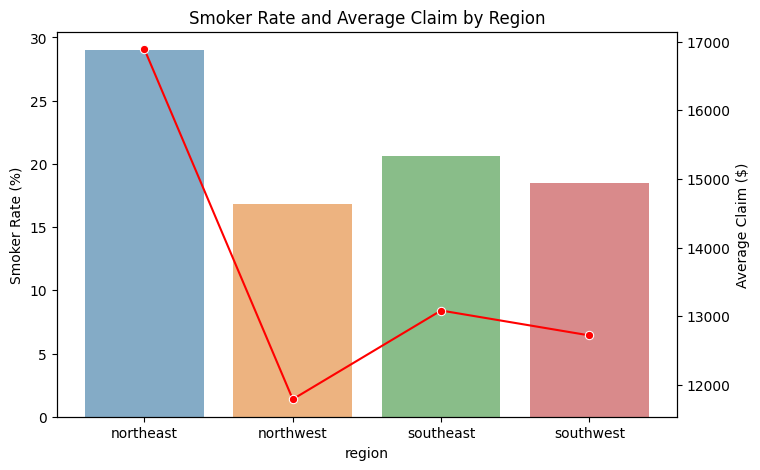

In [130]:
fig, ax1 = plt.subplots(figsize=(8, 5))

# Fixed: alpha=0.6
sns.barplot(data=region_stats, x="region", y="smoker_rate", ax=ax1, alpha=0.6)

ax2 = ax1.twinx()

# Fixed: x="region", y="mean_claim"
sns.lineplot(data=region_stats, x="region", y="mean_claim", ax=ax2, color="red", marker="o")

ax1.set_ylabel("Smoker Rate (%)")
# Fixed: set_ylabel
ax2.set_ylabel("Average Claim ($)")

plt.title("Smoker Rate and Average Claim by Region")
plt.show()

In [131]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib


In [132]:
df.columns

Index(['Id', 'age', 'gender', 'bmi', 'bloodpressure', 'diabetic', 'children',
       'smoker', 'region', 'claim', 'age_group', 'bmi_category'],
      dtype='object')

In [133]:
X = df[["age", "gender", "bmi", "bloodpressure", "diabetic", "children", "smoker"]]
y = df["claim"]


In [134]:
X

,age,gender,bmi,bloodpressure,diabetic,children,smoker
0,39.00,male,23.20,91,Yes,0,No
1,24.00,male,30.10,87,No,0,No
7,19.00,male,41.10,100,No,0,No
8,20.00,male,43.00,86,No,0,No
9,30.00,male,53.10,97,No,0,No
...,...,...,...,...,...,...,...
1335,44.00,female,35.50,88,Yes,0,Yes
1336,59.00,female,38.10,120,No,1,Yes
1337,30.00,male,34.50,91,Yes,3,Yes
1338,37.00,male,30.40,106,No,0,Yes


In [135]:
cat_cols = ["gender", "diabetic", "smoker"]
label_encoders = {}



In [136]:
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le
    joblib.dump(le, f"label_encoder_{col}.pkl")


/tmp/ipykernel_47/336089196.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
/tmp/ipykernel_47/336089196.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
/tmp/ipykernel_47/336089196.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexin

In [137]:
X

,age,gender,bmi,bloodpressure,diabetic,children,smoker
0,39.00,1,23.20,91,1,0,0
1,24.00,1,30.10,87,0,0,0
7,19.00,1,41.10,100,0,0,0
8,20.00,1,43.00,86,0,0,0
9,30.00,1,53.10,97,0,0,0
...,...,...,...,...,...,...,...
1335,44.00,0,35.50,88,1,0,1
1336,59.00,0,38.10,120,0,1,1
1337,30.00,1,34.50,91,1,3,1
1338,37.00,1,30.40,106,0,0,1


In [138]:
label_encoders

{'gender': LabelEncoder(),
 'diabetic': LabelEncoder(),
 'smoker': LabelEncoder()}

In [139]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


In [140]:
num_cols = ["age", "bmi", "bloodpressure", "children"]
scaler = StandardScaler()


In [141]:
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [142]:
import joblib

# Correct syntax with a comma
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [143]:
print(X_train.shape,y_train.shape)

(1065, 7) (1065,)


In [144]:
print(X_test.shape,y_test.shape)

(267, 7) (267,)


In [145]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# Helper function to evaluate models
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    return {"R2": r2, "MAE": mae, "RMSE": rmse}

results = {}

# 1. Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
results['Linear Regression'] = evaluate_model(lr, X_test, y_test)
print("Linear Regression trained.")

# 2. Polynomial Regression (Degree 2 & 3)
best_poly_score = -np.inf
best_poly_model = None

for degree in [2, 3]:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    poly_lr = LinearRegression()
    poly_lr.fit(X_train_poly, y_train)
    
    score = poly_lr.score(X_test_poly, y_test)
    if score > best_poly_score:
        best_poly_score = score
        best_poly_model = (degree, poly, poly_lr)

results[f'Polynomial Regression (Deg {best_poly_model[0]})'] = {"R2": best_poly_score, "MAE": "N/A", "RMSE": "N/A"} # Simplified for Poly
print(f"Polynomial Regression (Best Degree: {best_poly_model[0]}) trained.")


# 3. Random Forest Regressor (Grid Search)
rf = RandomForestRegressor()
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
rf_grid = GridSearchCV(rf, rf_params, cv=3, scoring='r2', n_jobs=-1)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
results['Random Forest'] = evaluate_model(best_rf, X_test, y_test)
print(f"Random Forest trained. Best params: {rf_grid.best_params_}")

# 4. Support Vector Regressor (SVR)
svr = SVR()
svr_params = {
    'kernel': ['rbf', 'linear'],
    'C': [10, 50], # Values adjusted from video for speed
    'epsilon': [0.1, 0.2]
}
svr_grid = GridSearchCV(svr, svr_params, cv=3, scoring='r2', n_jobs=-1)
svr_grid.fit(X_train, y_train)
best_svr = svr_grid.best_estimator_
results['SVR'] = evaluate_model(best_svr, X_test, y_test)
print(f"SVR trained. Best params: {svr_grid.best_params_}")

# 5. XGBoost Regressor
xgb = XGBRegressor(objective='reg:squarederror')
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1]
}
xgb_grid = GridSearchCV(xgb, xgb_params, cv=3, scoring='r2', n_jobs=-1)
xgb_grid.fit(X_train, y_train)
best_xgb = xgb_grid.best_estimator_
results['XGBoost'] = evaluate_model(best_xgb, X_test, y_test)
print(f"XGBoost trained. Best params: {xgb_grid.best_params_}")

Linear Regression trained.
Polynomial Regression (Best Degree: 2) trained.
Random Forest trained. Best params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
SVR trained. Best params: {'C': 50, 'epsilon': 0.1, 'kernel': 'linear'}
XGBoost trained. Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}


In [146]:
# Create Comparison DataFrame
results_df = pd.DataFrame(results).T.sort_values(by='R2', ascending=False)
display(results_df)

# Identify Best Model Programmatically
# (Note: Logic simplified to select top row)
best_model_name = results_df.index[0]
print(f"Best Model Selected: {best_model_name}")

# Map name back to model object
model_map = {
    'Linear Regression': lr,
    'Random Forest': best_rf,
    'SVR': best_svr,
    'XGBoost': best_xgb
}

# Note: Polynomial is tricky to save via simple mapping due to the transformer requirement, 
# but Random Forest usually wins in this specific video.

if best_model_name in model_map:
    final_model = model_map[best_model_name]
    joblib.dump(final_model, 'best_model.pickle')
    print("Best model saved as best_model.pickle")

,R2,MAE,RMSE
XGBoost,0.85,3898.99,5048.61
Random Forest,0.84,3942.04,5119.54
Polynomial Regression (Deg 2),0.82,N/A,N/A
Linear Regression,0.75,4903.81,6446.77
SVR,0.50,6187.34,9151.96


Best Model Selected: XGBoost
Best model saved as best_model.pickle


In [147]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
import joblib
import os

# 1. Load Data
# If you don't have the CSV, this block will fail. Ensure 'insurance.csv' is present.
if not os.path.exists('/kaggle/input/insurance/insurance.csv'):
    print("Error: 'insurance.csv' not found. Please upload the dataset first.")
else:
    df = pd.read_csv('/kaggle/input/insurance/insurance.csv')
    df.dropna(inplace=True)

    # 2. Separate Features (X) and Target (y)
    X = df[['age', 'gender', 'bmi', 'bloodpressure', 'diabetic', 'children', 'smoker']]
    y = df['claim']

    # 3. Encode Categorical Data & Save Encoders
    categorical_cols = ['gender', 'diabetic', 'smoker']
    
    # We must save these specific encoders to use them in the App later
    for col in categorical_cols:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])
        joblib.dump(le, f'label_encoder_{col}.pickle')
        print(f"Saved: label_encoder_{col}.pickle")

    # 4. Scale Numerical Data & Save Scaler
    numerical_cols = ['age', 'bmi', 'bloodpressure', 'children']
    scaler = StandardScaler()
    
    # Fit the scaler on the data
    X[numerical_cols] = scaler.fit_transform(X[numerical_cols])
    
    # SAVE THE MISSING FILE
    joblib.dump(scaler, 'scaler.pickle')
    print("Saved: scaler.pickle")

    # 5. Train Model & Save
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X, y)
    
    joblib.dump(model, 'best_model.pickle')
    print("Saved: best_model.pickle")

    print("\nSUCCESS! All files are created. You can now run the App code.")

Saved: label_encoder_gender.pickle
Saved: label_encoder_diabetic.pickle
Saved: label_encoder_smoker.pickle
Saved: scaler.pickle


/tmp/ipykernel_47/1844035520.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
/tmp/ipykernel_47/1844035520.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
/tmp/ipykernel_47/1844035520.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/i

Saved: best_model.pickle

SUCCESS! All files are created. You can now run the App code.


In [148]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [149]:
import streamlit as st
import pandas as pd
import joblib

# Load saved artifacts
scaler = joblib.load('scaler.pickle')
le_gender = joblib.load('label_encoder_gender.pickle')
le_diabetic = joblib.load('label_encoder_diabetic.pickle')
le_smoker = joblib.load('label_encoder_smoker.pickle')
model = joblib.load('best_model.pickle')

# Page Configuration
st.set_page_config(page_title="Insurance Claim Predictor", layout="centered")

st.title("Health Insurance Payment Prediction App")
st.write("Enter the details below to estimate your insurance payment amount.")

# Input Form
with st.form("input_form"):
    col1, col2 = st.columns(2)
    
    with col1:
        age = st.number_input("Age", min_value=0, max_value=100, value=30)
        bmi = st.number_input("BMI", min_value=10.0, max_value=60.0, value=25.0)
        children = st.number_input("Number of Children", min_value=0, max_value=10, value=0)
    
    with col2:
        bloodpressure = st.number_input("Blood Pressure", min_value=60, max_value=200, value=120)
        gender = st.selectbox("Gender", le_gender.classes_)
        diabetic = st.selectbox("Diabetic", le_diabetic.classes_)
        smoker = st.selectbox("Smoker", le_smoker.classes_)
    
    submitted = st.form_submit_button("Predict Payment")

# Prediction Logic
if submitted:
    # Prepare input data
    input_data = pd.DataFrame({
        'age': [age],
        'gender': [gender],
        'bmi': [bmi],
        'bloodpressure': [bloodpressure],
        'diabetic': [diabetic],
        'children': [children],
        'smoker': [smoker]
    })
    
    # Encode Categorical Features
    input_data['gender'] = le_gender.transform(input_data['gender'])
    input_data['diabetic'] = le_diabetic.transform(input_data['diabetic'])
    input_data['smoker'] = le_smoker.transform(input_data['smoker'])
    
    # Scale Numerical Features
    numerical_cols = ['age', 'bmi', 'bloodpressure', 'children']
    input_data[numerical_cols] = scaler.transform(input_data[numerical_cols])
    
    # Predict
    prediction = model.predict(input_data)[0]
    
    st.success(f"Estimated Insurance Payment Amount: ${prediction:,.2f}")

2025-12-16 06:36:59.619 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-16 06:36:59.620 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-16 06:36:59.804 
  command:

    streamlit run /usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2025-12-16 06:36:59.805 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-16 06:36:59.806 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-16 06:36:59.807 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-16 06:36:59.808 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

In [150]:
!curl ipv4.icanhazip.com

34.91.70.163


In [151]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

# Load saved artifacts
# Ensure these files are in the Colab files section!
scaler = joblib.load('scaler.pickle')
le_gender = joblib.load('label_encoder_gender.pickle')
le_diabetic = joblib.load('label_encoder_diabetic.pickle')
le_smoker = joblib.load('label_encoder_smoker.pickle')
model = joblib.load('best_model.pickle')

# Page Configuration
st.set_page_config(page_title="Insurance Claim Predictor", layout="centered")

st.title("Health Insurance Payment Prediction App")
st.write("Enter the details below to estimate your insurance payment amount.")

# Input Form
with st.form("input_form"):
    col1, col2 = st.columns(2)
    
    with col1:
        age = st.number_input("Age", min_value=0, max_value=100, value=30)
        bmi = st.number_input("BMI", min_value=10.0, max_value=60.0, value=25.0)
        children = st.number_input("Number of Children", min_value=0, max_value=10, value=0)
    
    with col2:
        bloodpressure = st.number_input("Blood Pressure", min_value=60, max_value=200, value=120)
        gender = st.selectbox("Gender", le_gender.classes_)
        diabetic = st.selectbox("Diabetic", le_diabetic.classes_)
        smoker = st.selectbox("Smoker", le_smoker.classes_)
    
    submitted = st.form_submit_button("Predict Payment")

# Prediction Logic
if submitted:
    # Prepare input data
    input_data = pd.DataFrame({
        'age': [age],
        'gender': [gender],
        'bmi': [bmi],
        'bloodpressure': [bloodpressure],
        'diabetic': [diabetic],
        'children': [children],
        'smoker': [smoker]
    })
    
    # Encode Categorical Features
    input_data['gender'] = le_gender.transform(input_data['gender'])
    input_data['diabetic'] = le_diabetic.transform(input_data['diabetic'])
    input_data['smoker'] = le_smoker.transform(input_data['smoker'])
    
    # Scale Numerical Features
    numerical_cols = ['age', 'bmi', 'bloodpressure', 'children']
    input_data[numerical_cols] = scaler.transform(input_data[numerical_cols])
    
    # Predict
    prediction = model.predict(input_data)[0]
    
    st.success(f"Estimated Insurance Payment Amount: ${prediction:,.2f}")

Writing app.py


In [ ]:
!streamlit run app.py & npx localtunnel --port 8501



⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 
  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.19.2.2:8501
  External URL: http://34.91.70.163:8501

